# QSilver: Introduction to Complex Numbers II

Este notebook desarrolla la geometría de estados de un qubit, la esfera de Bloch, fases cuánticas, compuertas de Pauli, Hadamard, compuertas de fase y CRZ. Se asume que ya se conocen números complejos, forma polar, conjugación, normalización de vectores complejos y la regla de Born.

La notación de Dirac se escribe sin macros personalizadas para maximizar compatibilidad en JupyterLab, Anaconda y Google Colab. Por ejemplo:

$$
\left|0\right\rangle,\qquad \left|1\right\rangle,\qquad \left|\psi\right\rangle=\alpha\left|0\right\rangle+\beta\left|1\right\rangle.
$$

El notebook usa visualizaciones con Matplotlib y, cuando Qiskit está disponible, visualizaciones nativas de Qiskit.

## Objetivos de aprendizaje

Al finalizar el notebook deberías poder convertir un estado de un qubit entre amplitudes complejas y coordenadas de Bloch, distinguir fase global de fase relativa, interpretar Pauli, Hadamard, S, T y CRZ como transformaciones geométricas, y verificar estas ideas mediante Python y Qiskit.

In [1]:
import sys, subprocess, importlib, math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

np.set_printoptions(precision=4, suppress=True)

# Matrices básicas
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
S = np.array([[1, 0], [0, 1j]], dtype=complex)
Sdg = S.conj().T
T = np.array([[1, 0], [0, np.exp(1j*np.pi/4)]], dtype=complex)
Tdg = T.conj().T

zero = np.array([1, 0], dtype=complex)
one = np.array([0, 1], dtype=complex)
plus = (zero + one) / np.sqrt(2)
minus = (zero - one) / np.sqrt(2)


## 1. Estado puro de un qubit y esfera de Bloch

Un estado puro de un qubit tiene la forma

$$
\left|\psi\right\rangle=\alpha\left|0\right\rangle+\beta\left|1\right\rangle,
\qquad |\alpha|^2+|\beta|^2=1.
$$

Salvo una fase global, puede escribirse como

$$
\left|\psi\right\rangle=
\cos\frac{\theta}{2}\left|0\right\rangle+
e^{i\phi}\sin\frac{\theta}{2}\left|1\right\rangle.
$$

El ángulo $\theta$ controla probabilidades y $\phi$ controla fase relativa.

In [2]:
def normalize_state(psi):
    psi = np.asarray(psi, dtype=complex)
    norm = np.linalg.norm(psi)
    if norm == 0:
        raise ValueError("El estado cero no puede normalizarse")
    return psi / norm


def state_from_angles(theta, phi):
    # Devuelve el vector de estado asociado a theta y phi.
    return np.array([np.cos(theta/2), np.exp(1j*phi)*np.sin(theta/2)], dtype=complex)


def bloch_vector(psi):
    # Convierte un estado normalizado de un qubit en vector de Bloch.
    psi = normalize_state(psi)
    alpha, beta = psi
    x = 2*np.real(np.conjugate(alpha)*beta)
    y = 2*np.imag(np.conjugate(alpha)*beta)
    z = abs(alpha)**2 - abs(beta)**2
    return np.array([x, y, z], dtype=float)


def probs_z(psi):
    psi = normalize_state(psi)
    return {"0": float(abs(psi[0])**2), "1": float(abs(psi[1])**2)}

print("Bloch(|0>) =", bloch_vector(zero))
print("Bloch(|1>) =", bloch_vector(one))
print("Bloch(|+>) =", bloch_vector(plus))

Bloch(|0>) = [0. 0. 1.]
Bloch(|1>) = [ 0.  0. -1.]
Bloch(|+>) = [1. 0. 0.]


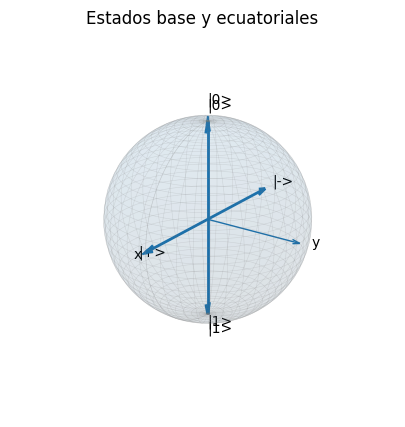

In [3]:
def draw_bloch(vectors=None, labels=None, title="Esfera de Bloch", trajectories=None, elev=22, azim=35):
    # Dibuja una esfera de Bloch sencilla con vectores y trayectorias opcionales.
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    u = np.linspace(0, 2*np.pi, 80)
    v = np.linspace(0, np.pi, 40)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, alpha=0.07, linewidth=0)
    ax.plot_wireframe(xs, ys, zs, color="gray", alpha=0.18, linewidth=0.4)

    # ejes
    axes = [np.array([1,0,0]), np.array([0,1,0]), np.array([0,0,1])]
    names = ["x", "y", "|0>"]
    for a, name in zip(axes, names):
        ax.quiver(0,0,0,*a, length=1.05, arrow_length_ratio=0.08, linewidth=1)
        ax.text(*(1.18*a), name)
    ax.text(0,0,-1.2,"|1>")

    if trajectories:
        for traj in trajectories:
            traj = np.array(traj)
            ax.plot(traj[:,0], traj[:,1], traj[:,2], linewidth=2)
    if vectors is not None:
        for k, vec in enumerate(vectors):
            vec = np.array(vec, dtype=float)
            ax.quiver(0,0,0,*vec, length=1.0, arrow_length_ratio=0.12, linewidth=2)
            if labels:
                ax.text(*(1.12*vec), labels[k])

    ax.set_xlim(-1.1,1.1); ax.set_ylim(-1.1,1.1); ax.set_zlim(-1.1,1.1)
    ax.set_box_aspect([1,1,1])
    ax.set_axis_off()
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title)
    plt.show()

# Visualización básica
states = [zero, one, plus, minus]
labels = ["|0>", "|1>", "|+>", "|->"]
draw_bloch([bloch_vector(s) for s in states], labels, "Estados base y ecuatoriales")

## 2. Fase global y fase relativa

Los vectores $\left|\psi\right\rangle$ y $e^{i\gamma}\left|\psi\right\rangle$ representan el mismo estado físico. Esa fase común no altera probabilidades ni posición en la esfera de Bloch.

En cambio, cambiar solo la fase relativa entre $\left|0\right\rangle$ y $\left|1\right\rangle$ sí puede cambiar el estado físico. La fase relativa suele volverse visible después de aplicar una compuerta que mezcle amplitudes, como Hadamard.

In [ ]:
psi = state_from_angles(np.pi/2, np.pi/3)
psi_global = np.exp(1j*np.pi/2) * psi

print("psi =", psi)
print("i psi =", psi_global)
print("Probabilidades psi:", probs_z(psi))
print("Probabilidades i psi:", probs_z(psi_global))
print("Vector Bloch psi:", bloch_vector(psi))
print("Vector Bloch i psi:", bloch_vector(psi_global))

draw_bloch([bloch_vector(psi), bloch_vector(psi_global)], ["psi", "i psi"], "Fase global: mismo punto")

In [ ]:
# Fase relativa: los puntos se mueven sobre el ecuador.
phis = np.linspace(0, 2*np.pi, 100)
trajectory = [bloch_vector(state_from_angles(np.pi/2, phi)) for phi in phis]
selected = [state_from_angles(np.pi/2, 0), state_from_angles(np.pi/2, np.pi/2), state_from_angles(np.pi/2, np.pi)]
labels = ["phi=0", "phi=pi/2", "phi=pi"]
draw_bloch([bloch_vector(s) for s in selected], labels, "Fase relativa en el ecuador", trajectories=[trajectory])

In [ ]:
# La fase relativa no cambia la medición Z inmediata, pero sí cambia después de H.
phis = np.linspace(0, 2*np.pi, 300)
prob0_direct = []
prob0_after_h = []
for phi in phis:
    psi = state_from_angles(np.pi/2, phi)
    prob0_direct.append(probs_z(psi)["0"])
    prob0_after_h.append(probs_z(H @ psi)["0"])

plt.figure(figsize=(7,4))
plt.plot(phis, prob0_direct, label="Pr(0) medición directa")
plt.plot(phis, prob0_after_h, label="Pr(0) después de H")
plt.xlabel("fase relativa phi")
plt.ylabel("probabilidad")
plt.title("La fase relativa se revela al cambiar de base")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 3. Operadores Pauli y rotaciones de $\pi$

Las compuertas $X$, $Y$ y $Z$ son rotaciones de $\pi$ alrededor de los ejes $x$, $y$ y $z$ de la esfera de Bloch. Esta interpretación geométrica complementa la multiplicación matricial: muestra qué componente del vector se preserva y cuáles se invierten.

In [ ]:
def apply_gate(gate, psi):
    return normalize_state(gate @ normalize_state(psi))

psi0 = state_from_angles(np.pi/3, np.pi/4)
gates = {"psi": I, "X psi": X, "Y psi": Y, "Z psi": Z}
vectors = [bloch_vector(apply_gate(g, psi0)) for g in gates.values()]
draw_bloch(vectors, list(gates.keys()), "Efecto de X, Y y Z sobre un mismo estado")

In [ ]:
# Tablas algebraicas mínimas de Pauli
for name, gate in [("X", X), ("Y", Y), ("Z", Z)]:
    print(name)
    print(gate)
    print("U dagger U =")
    print(gate.conj().T @ gate)
    print()

### Ejercicio guiado: acción de $Y$

Para

$$
\left|\psi\right\rangle=\begin{pmatrix} i/\sqrt{6} \ (2+i)/\sqrt{6} \end{pmatrix},
$$

se tiene

$$
Y\left|\psi\right\rangle=
\begin{pmatrix}0&-i\ i&0\end{pmatrix}
\begin{pmatrix} i/\sqrt{6} \ (2+i)/\sqrt{6} \end{pmatrix}
=
\begin{pmatrix} (1-2i)/\sqrt{6} \ -1/\sqrt{6} \end{pmatrix}.
$$

El punto conceptual es que $Y$ no solo intercambia componentes: también introduce fases imaginarias.

In [ ]:
psi_y = np.array([1j/np.sqrt(6), (2+1j)/np.sqrt(6)], dtype=complex)
result_y = Y @ psi_y
print("Y psi =", result_y)
print("Norma:", np.linalg.norm(result_y))
draw_bloch([bloch_vector(psi_y), bloch_vector(result_y)], ["psi", "Y psi"], "Acción de Y")

## 4. Hadamard y su eje geométrico

Hadamard transforma información entre la dirección $z$ y la dirección $x$. Algebraicamente,

$$
H\left|0\right\rangle=\left|+\right\rangle,\qquad
H\left|1\right\rangle=\left|-\right\rangle.
$$

Geométricamente puede entenderse como una rotación de $\pi$ alrededor del eje proporcional a $(1,0,1)$.

In [ ]:
axis_h = np.array([1,0,1], dtype=float) / np.sqrt(2)
minus_axis_h = -axis_h
draw_bloch([axis_h, minus_axis_h], ["eigen +1", "eigen -1"], "Eje de Hadamard")

# Verificación del eigenestado asociado al eje +1
psi_h_plus = normalize_state(np.array([np.cos(np.pi/8), np.sin(np.pi/8)], dtype=complex))
print("psi_h_plus =", psi_h_plus)
print("H psi_h_plus =", H @ psi_h_plus)
print("¿Coinciden?", np.allclose(H @ psi_h_plus, psi_h_plus))

In [ ]:
# Hadamard convierte fase relativa en diferencia de probabilidad.
for state_name, st in [("|+>", plus), ("|->", minus), ("(|0>+i|1>)/sqrt(2)", np.array([1,1j])/np.sqrt(2))]:
    print(state_name)
    print("Antes de H:", probs_z(st))
    print("Después de H:", probs_z(H @ st))
    print()

## 5. Compuertas de fase: S, S†, T y T†

Las compuertas de fase son diagonales en la base computacional. Por tanto, no cambian los módulos de las amplitudes, pero sí cambian la fase relativa.

$$
S=\begin{pmatrix}1&0\0&i\end{pmatrix},\qquad
T=\begin{pmatrix}1&0\0&e^{i\pi/4}\end{pmatrix}.
$$

En la esfera de Bloch, actúan como rotaciones alrededor del eje $z$.

In [ ]:
# Comparar S y T sobre |+>
states_phase = [plus, T @ plus, S @ plus, Tdg @ plus, Sdg @ plus]
labels_phase = ["|+>", "T|+>", "S|+>", "Tdg|+>", "Sdg|+>"]
draw_bloch([bloch_vector(s) for s in states_phase], labels_phase, "Efectos de S, T y sus inversas")

In [ ]:
# Trayectoria continua de rotaciones z sobre |+>
def rz_matrix(lam):
    return np.array([[np.exp(-1j*lam/2), 0], [0, np.exp(1j*lam/2)]], dtype=complex)

angles = np.linspace(0, 2*np.pi, 120)
traj_rz = [bloch_vector(rz_matrix(a) @ plus) for a in angles]
draw_bloch([bloch_vector(plus), bloch_vector(S @ plus), bloch_vector(T @ plus)], ["|+>", "S|+>", "T|+>"], "Rotación alrededor de z", trajectories=[traj_rz])

### Ejercicio guiado: secuencia $X,H,S$

Partiendo de $\left|0\right\rangle$:

1. $X\left|0\right\rangle=\left|1\right\rangle$.
2. $H\left|1\right\rangle=(\left|0\right\rangle-\left|1\right\rangle)/\sqrt{2}$.
3. $S$ multiplica la componente $\left|1\right\rangle$ por $i$.

Por tanto,

$$
S H X\left|0\right\rangle =
\frac{1}{\sqrt{2}}\left|0\right\rangle-
\frac{i}{\sqrt{2}}\left|1\right\rangle.
$$

In [ ]:
state_xhs = S @ H @ X @ zero
print(state_xhs)
draw_bloch([bloch_vector(zero), bloch_vector(X@zero), bloch_vector(H@X@zero), bloch_vector(state_xhs)],
           ["inicio", "X", "HX", "SHX"],
           "Trayectoria de la secuencia X, H, S")

## 6. CRZ: rotación de fase controlada

La compuerta $CRZ(\lambda)$ aplica una rotación alrededor de $z$ al qubit objetivo condicionada al estado del control. Su forma matricial convencional es

$$
CRZ(\lambda)=
\begin{pmatrix}
1&0&0&0\
0&1&0&0\
0&0&e^{-i\lambda/2}&0\
0&0&0&e^{i\lambda/2}
\end{pmatrix}.
$$

La operación es coherente: no mide el control.

In [ ]:
def crz_matrix(lam):
    return np.diag([1, 1, np.exp(-1j*lam/2), np.exp(1j*lam/2)]).astype(complex)

lam = np.pi/2
CRZ = crz_matrix(lam)
print(CRZ)

# Efecto sobre los estados base de dos qubits
basis2 = {
    "00": np.array([1,0,0,0], dtype=complex),
    "01": np.array([0,1,0,0], dtype=complex),
    "10": np.array([0,0,1,0], dtype=complex),
    "11": np.array([0,0,0,1], dtype=complex),
}
for label, vec in basis2.items():
    out = CRZ @ vec
    print(label, "->", out)

## 7. Visualización con Qiskit

Las siguientes celdas intentan importar Qiskit. Si no está instalado, se intenta instalar `qiskit` y `qiskit-aer`. En algunos entornos, las visualizaciones 3D pueden depender de paquetes gráficos adicionales; por eso el notebook mantiene también visualizaciones propias con Matplotlib.

In [ ]:
from IPython.display import display

qiskit_available = False
qiskit_viz_ok = False
try:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
    try:
        from qiskit.visualization import plot_bloch_vector, plot_bloch_multivector
        qiskit_viz_ok = True
    except Exception as exc:
        print("Visualización nativa de Qiskit no disponible:", exc)
    qiskit_available = True
except Exception as exc:
    print("Qiskit no está disponible en este entorno:", exc)
    print("En Google Colab puede instalarse ejecutando: !pip install qiskit qiskit-aer")


In [ ]:
# Construcción de estados y visualización con Qiskit
if qiskit_available:
    qc = QuantumCircuit(1)
    qc.h(0)
    qc.s(0)
    state = Statevector.from_instruction(qc)
    print(state)
    print("Vector de Bloch calculado manualmente:", bloch_vector(np.array(state.data)))

    if qiskit_viz_ok:
        display(plot_bloch_multivector(state))

    draw_bloch([bloch_vector(np.array(state.data))], ["S H |0>"], "Misma visualización con Matplotlib")
else:
    # Alternativa equivalente con NumPy cuando Qiskit no está instalado.
    state = S @ H @ zero
    print("Estado calculado con NumPy:", state)
    print("Vector de Bloch:", bloch_vector(state))
    draw_bloch([bloch_vector(state)], ["S H |0>"], "Visualización con Matplotlib")


In [ ]:
# Visualización de X, Y, Z, H, S, T
if qiskit_available:
    for name, instruction in [("X", "x"), ("Y", "y"), ("Z", "z"), ("H", "h"), ("S", "s"), ("T", "t")]:
        qc = QuantumCircuit(1)
        qc.h(0)  # estado inicial |+>
        getattr(qc, instruction)(0)
        st = Statevector.from_instruction(qc)
        print(name, np.array(st.data), bloch_vector(np.array(st.data)))
else:
    print("Qiskit no disponible; se muestran resultados equivalentes con NumPy.")
    for name, gate in [("X", X), ("Y", Y), ("Z", Z), ("H", H), ("S", S), ("T", T)]:
        st = gate @ plus
        print(name, st, bloch_vector(st))

vectors = []
labels = []
for name, gate in [("I", I), ("X", X), ("Y", Y), ("Z", Z), ("H", H), ("S", S), ("T", T)]:
    vectors.append(bloch_vector(gate @ plus))
    labels.append(name + "|+>")
draw_bloch(vectors, labels, "Compuertas aplicadas a |+>")


In [ ]:
# CRZ en Qiskit y matriz equivalente con NumPy
lambda_angle = np.pi/2
if qiskit_available:
    qc2 = QuantumCircuit(2)
    qc2.x(0)       # control en 1
    qc2.h(1)       # objetivo en superposición
    qc2.crz(lambda_angle, 0, 1)
    state2 = Statevector.from_instruction(qc2)
    print(qc2)
    print(state2)
else:
    # Orden conceptual: |control, objetivo>. Estado inicial |1> \otimes |+>.
    state2_initial = np.kron(one, plus)
    state2 = crz_matrix(lambda_angle) @ state2_initial
    print("Estado de dos qubits calculado con NumPy:", state2)

# El estado de dos qubits no se representa en una sola esfera de Bloch si hay correlaciones.
# Aquí observamos que la fase aparece en las componentes con control activado.


## 8. Ejercicios propuestos

1. Para $\left|\psi\right\rangle=\cos(\pi/6)\left|0\right\rangle+e^{i\pi/3}\sin(\pi/6)\left|1\right\rangle$, calcule el vector de Bloch y verifíquelo con código.
2. Compare $\left|\psi\right\rangle$ y $-i\left|\psi\right\rangle$ mediante probabilidades y vector de Bloch.
3. Partiendo de $\left|+\right\rangle$, aplique $S$, $T$ y $T^\dagger$. Explique las posiciones relativas sobre el ecuador.
4. Construya en Qiskit la secuencia $X,H,S$ y verifique que produce $(\left|0\right\rangle-i\left|1\right\rangle)/\sqrt2$.
5. Explique por qué aplicar $Z$ a $\left|1\right\rangle$ no produce un estado físicamente distinguible de $\left|1\right\rangle$, pero aplicar $Z$ a $\left|+\right\rangle$ sí cambia el punto de Bloch.
6. Use CRZ con $\lambda=\pi$ y determine qué componentes del vector de dos qubits adquieren fase.

## Resumen final

La esfera de Bloch surge porque un estado puro de un qubit tiene dos parámetros físicos después de normalizar y eliminar fase global. La latitud describe probabilidades en la base computacional y la longitud describe fase relativa.

La fase global no cambia ningún resultado físico; la fase relativa sí puede modificar resultados cuando el circuito cambia de base y produce interferencia. Las compuertas $X$, $Y$ y $Z$ son rotaciones de $\pi$ alrededor de ejes cartesianos; Hadamard rota alrededor de un eje inclinado; $S$ y $T$ realizan rotaciones discretas alrededor de $z$; CRZ introduce una fase condicionada de forma coherente.

La combinación de álgebra, geometría y código permite interpretar estados de un qubit con precisión matemática y con intuición visual.